In [1]:
# Import required modules
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point
import xarray as xr
import contextily as ctx
from adjustText import adjust_text  # pip install adjustText
from pathlib import Path

# Add that all figures should be inlined
%matplotlib inline
#%matplotlib notebook

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_diurnal_pattern(nc_file, variables=['SWRadAtm', 'LWRadAtm', 'scalarNetRadiation_total']):
    """
    Plot diurnal cycles (mean, 25-75%, min-max) for selected radiation variables from a NetCDF file.

    Parameters:
    - nc_file (str): Path to NetCDF file.
    - variables (list of str): Variables to plot.
    """
    # Open dataset without automatic time decoding, to handle manually if needed
    ds = xr.open_dataset(nc_file, decode_times=False)

    # Convert variables of interest to DataFrame, selecting the first hru
    df = ds[variables].isel(hru=0).to_dataframe().reset_index()

    # Handle time coordinate: convert numeric seconds to datetime if needed
    if np.issubdtype(df['time'].dtype, np.number):
        df['time'] = pd.to_datetime(
            df['time'], unit='s', origin=pd.Timestamp('1990-01-01')
        )
    else:
        df['time'] = pd.to_datetime(df['time'])

    # Extract hour of day
    df['hour'] = df['time'].dt.hour

    # Prepare plot
    nvars = len(variables)
    fig, axes = plt.subplots(nvars, 1, figsize=(10, 4 * nvars), sharex=True)
    if nvars == 1:
        axes = [axes]

    for ax, var in zip(axes, variables):
        # Group by hour
        grouped = df.groupby('hour')[var]
        hourly_mean = grouped.mean()
        hourly_25 = grouped.quantile(0.25)
        hourly_75 = grouped.quantile(0.75)
        hourly_min = grouped.min()
        hourly_max = grouped.max()

        hours = hourly_mean.index.values

        # Plot mean, IQR, and range
        ax.plot(hours, hourly_mean.values, marker='o', label='Mean')
        ax.fill_between(hours, hourly_25.values, hourly_75.values, alpha=0.3, label='25-75%')
        ax.fill_between(hours, hourly_min.values, hourly_max.values, alpha=0.5, label='Min-Max')

        ax.set_title(f'Diurnal Pattern of {var}')
        #ax.set_ylabel(f'{var} ({ds[var].units})')
        ax.grid(True)
        ax.legend()

    # X-axis formatting
    axes[-1].set_xlabel('Hour of Day')
    plt.xticks(np.arange(0, 24, 1))
    plt.tight_layout()
    plt.show()

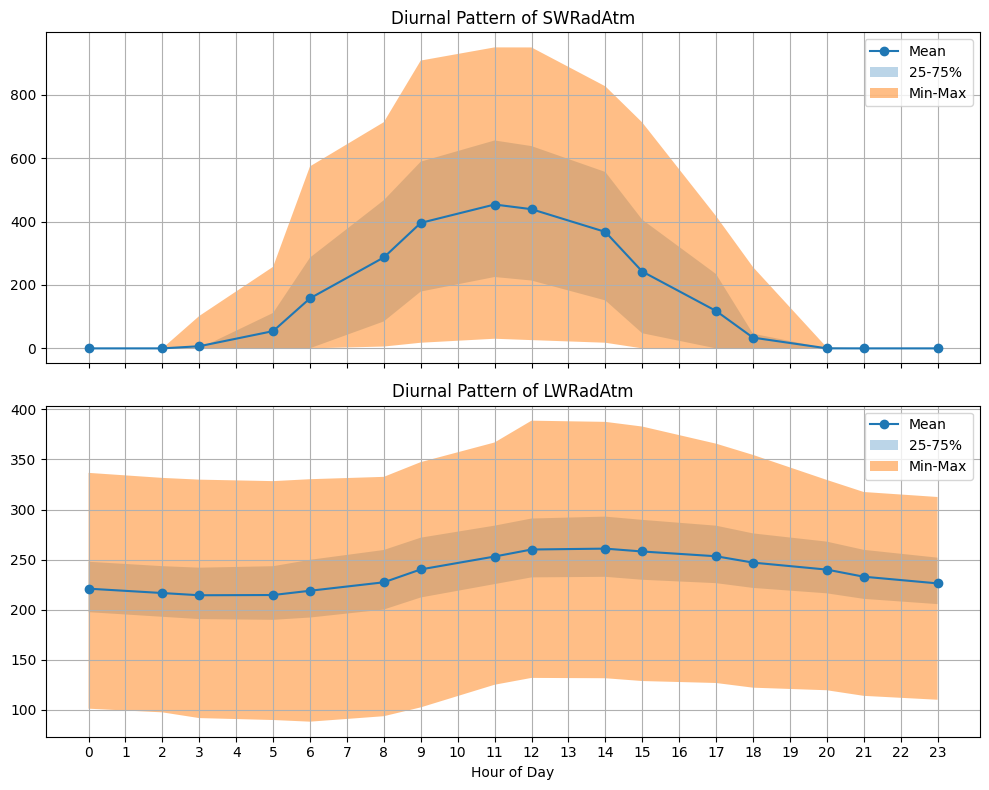

In [3]:
nc_file = '/Users/dcasson/Data/snow_analysis/bow/gpepmean_output/bow001_local_H101_timestep.nc'
variables = ['SWRadAtm', 'LWRadAtm']
plot_diurnal_pattern(nc_file, variables)

/var/folders/46/6y3tkg051374dmsgd2w6l9gw0000gn/T/ipykernel_40776/2486579817.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1400x800 with 0 Axes>

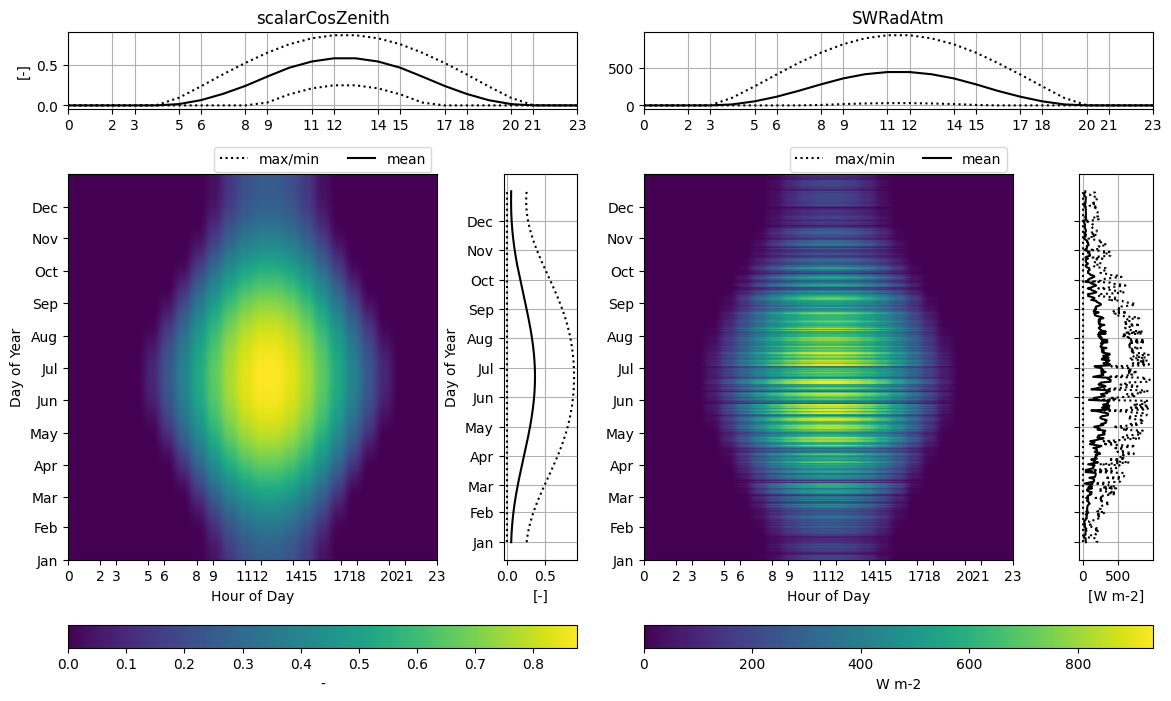

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.ndimage import gaussian_filter


def select_hru_dataset(dataset, hru_id):
    """
    Select an HRU slice: if only one HRU, select it; else match 'hruId' coordinate or index.
    """
    if 'hru' in dataset.dims and dataset.sizes['hru'] == 1:
        return dataset.isel(hru=0)
    if 'hruId' in dataset.coords:
        ids = dataset['hruId'].values
        matches = np.where(ids == hru_id)[0]
        if matches.size > 0:
            return dataset.isel(hru=matches[0])
    if 'hru' in dataset.dims and isinstance(hru_id, int) and 0 <= hru_id < dataset.sizes['hru']:
        return dataset.isel(hru=hru_id)
    raise ValueError(f"HRU {hru_id} not found in dataset")


def compare_fingerprints(ds, var1, var2, hru_id,
                         smooth=False, sigma=4,
                         figsize=(14, 8)):
    """
    Create side-by-side fingerprint comparison for two variables:
      - Row 0: diurnal summary plots (two columns)
      - Row 1: fingerprint matrices with seasonal summaries to their right
      - Row 2: horizontal colorbars beneath each fingerprint matrix

    Seasonal summaries are narrower; colorbars are only legends.
    """
    # Slice out the specified HRU
    ds = select_hru_dataset(ds, hru_id)

    # Decode time to pandas.DatetimeIndex
    times = pd.to_datetime(ds['time'].values)
    minutes = times.hour * 60 + times.minute
    days    = times.dayofyear

    # Unique grid axes
    unique_min = np.unique(minutes)
    unique_day = np.arange(1, 367)

    # Function to build and optionally smooth a matrix
    def build_matrix(arr):
        Z = np.full((366, len(unique_min)), np.nan)
        for m, d, v in zip(minutes, days, arr):
            if 1 <= d <= 366:
                i = np.where(unique_min == m)[0][0]
                Z[d-1, i] = v
        return gaussian_filter(Z, sigma) if smooth else Z

    # Extract arrays, collapsing HRU dimension if present
    a1 = ds[var1].values.squeeze()
    a2 = ds[var2].values.squeeze()
    Z1 = build_matrix(a1)
    Z2 = build_matrix(a2)

    # Compute diurnal and seasonal stats
    def stats(Z):
        return (
            np.nanmax(Z, axis=0), np.nanmin(Z, axis=0), np.nanmean(Z, axis=0),
            np.nanmax(Z, axis=1), np.nanmin(Z, axis=1), np.nanmean(Z, axis=1)
        )
    dmax1,dmin1,dmean1,smax1,smin1,smean1 = stats(Z1)
    dmax2,dmin2,dmean2,smax2,smin2,smean2 = stats(Z2)
    u1 = ds[var1].attrs.get('units', '')
    u2 = ds[var2].attrs.get('units', '')

        # Tick locations and labels (automatically from timestep)
    # Determine unique hour values present (e.g., 0,3,6,...)
    unique_hours = np.unique(times.hour)
    x_ticks = unique_hours
    x_labels = unique_hours.astype(int)
    # For matrix extent, convert unique_min to hours
    x_hours = unique_min / 60.0

    # Month-start ticks
    month_days = [31,28,31,30,31,30,31,31,30,31,30,31]
    month_starts = np.concatenate(([1], np.cumsum(month_days)[:-1] + 1))
    y_ticks = month_starts
    y_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    # Set up figure grid: 3 rows × 4 columns
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        3, 4,
        width_ratios=[5,1,5,1],  # wide fingerprint, narrow seasonal
        height_ratios=[1, 5, 0.3],
        hspace=0.4, wspace=0.3
    )
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        3, 4,
        width_ratios=[5,1,5,1],  # wide fingerprint, narrow seasonal
        height_ratios=[1, 5, 0.3],
        hspace=0.4, wspace=0.3
    )

    # Diurnal summary axes
    ax_d1 = fig.add_subplot(gs[0, 0:2])
    ax_d2 = fig.add_subplot(gs[0, 2:4])

    # Fingerprint and seasonal axes
    ax_fp1 = fig.add_subplot(gs[1, 0])
    ax_se1 = fig.add_subplot(gs[1, 1])
    ax_fp2 = fig.add_subplot(gs[1, 2])
    ax_se2 = fig.add_subplot(gs[1, 3])

    # Colorbar axes (horizontal legends)
    ax_cb1 = fig.add_subplot(gs[2, 0:2])
    ax_cb2 = fig.add_subplot(gs[2, 2:4])

    # Plot diurnal summaries with bottom legends
    for ax, dmax, dmin, dmean, var, units in [
        (ax_d1, dmax1, dmin1, dmean1, var1, u1),
        (ax_d2, dmax2, dmin2, dmean2, var2, u2)
    ]:
        ax.plot(x_hours, dmax,  'k:', label='max/min')
        ax.plot(x_hours, dmin,  'k:')
        ax.plot(x_hours, dmean,'k-', label='mean')
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_labels)
        ax.set_xlim(x_hours.min(), x_hours.max())
        ax.set_title(var)
        ax.grid(True)
        # legend positioned at bottom of each summary
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=2)
    ax_d1.set_ylabel(f'[{u1}]')

    # Plot fingerprint matrices and capture images
    im1 = ax_fp1.imshow(
        Z1,
        origin='lower',
        aspect='auto',
        extent=[x_hours.min(), x_hours.max(), 1, 366]
    )
    im2 = ax_fp2.imshow(
        Z2,
        origin='lower',
        aspect='auto',
        extent=[x_hours.min(), x_hours.max(), 1, 366]
    )
    for ax in [ax_fp1, ax_fp2]:
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_labels)
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_labels)
        ax.set_xlabel('Hour of Day')
    ax_fp1.set_ylabel('Day of Year')

    # Plot seasonal summaries
    ax_se1.plot(smax1, unique_day, 'k:')
    ax_se1.plot(smin1, unique_day, 'k:')
    ax_se1.plot(smean1, unique_day, 'k-')
    ax_se2.plot(smax2, unique_day, 'k:')
    ax_se2.plot(smin2, unique_day, 'k:')
    ax_se2.plot(smean2, unique_day, 'k-')
    for ax, units in [(ax_se1, u1), (ax_se2, u2)]:
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_labels)
        ax.set_xlabel(f'[{units}]')
        ax.grid(True)
    ax_se1.set_ylabel('Day of Year')
    ax_se2.set_yticklabels([])

    # Horizontal colorbars for each fingerprint
    fig.colorbar(im1, cax=ax_cb1, orientation='horizontal', label=u1)
    fig.colorbar(im2, cax=ax_cb2, orientation='horizontal', label=u2)

    plt.tight_layout()
    return fig, {
        'diurnal1': ax_d1, 'diurnal2': ax_d2,
        'finger1': ax_fp1, 'season1': ax_se1,
        'finger2': ax_fp2, 'season2': ax_se2,
        'cbar1': ax_cb1, 'cbar2': ax_cb2
    }



# Example usage:
ds = xr.open_dataset('/Users/dcasson/Data/snow_analysis/bow/gpepmean_output/bow001_local_H101_timestep.nc')
fig, axes = compare_fingerprints(ds, 'scalarCosZenith', 'SWRadAtm',
                                 hru_id=0, smooth=False, sigma=4)
plt.show()

## Read data